# 📉 Cost Function for Logistic Regression

---

# 1. Executive Summary

This lecture introduces the **cost function** for logistic regression - a crucial concept that measures how well our model fits the training data and guides the parameter selection process. While linear regression uses squared error, this cost function is unsuitable for logistic regression because it creates a **non-convex** surface with many local minima, making gradient descent unreliable.

Instead, we use a **logistic loss function** derived from maximum likelihood estimation that results in a **convex** cost function, guaranteeing that gradient descent can find the global minimum. The lecture shows why squared error fails, introduces the new loss function intuitively, and presents a simplified mathematical form that's easier to implement.

By the end of this module, you'll understand: why squared error doesn't work for classification, the intuition behind logistic loss, how the loss function behaves for different predictions, and the simplified mathematical expression that unifies both cases (y=1 and y=0).

---

# 2. Key Concepts & Glossary

| **Term** | **Definition** |
|----------|----------------|
| **Cost Function** | A function \( $J(\vec{w}, b)$ \) that measures how well a model fits the entire training set - the average of losses over all examples |
| **Loss Function** | A function \( $L(f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)})$ \) that measures error on a **single** training example |
| **Convex Function** | A bowl-shaped function with a single global minimum - guarantees gradient descent will converge |
| **Non-convex Function** | A wiggly function with multiple local minima - gradient descent can get stuck |
| **Logistic Loss** | The loss function used for logistic regression: \( $L = -\log(f(\vec{x}))$ \) when \( $y=1$ \), and \( $L = -\log(1-f(\vec{x}))$ \) when \( $y=0$ \) |
| **Maximum Likelihood Estimation** | A statistical principle used to derive the logistic cost function - ensures efficient parameter estimation |
| **Global Minimum** | The point where cost function achieves its lowest possible value across the entire parameter space |
| **Local Minimum** | A point where cost function is lower than nearby points, but not necessarily the lowest overall |
| **Gradient Descent** | An optimization algorithm that iteratively adjusts parameters to minimize the cost function |
| **Squared Error** | The cost function used for linear regression: \( $\frac{1}{2}(f(x) - y)^2$ \) - **not suitable** for logistic regression |

---

# 3. Important Data Points

## Key Formulas

| **Formula** | **Description** | **Terms** |
|-------------|-----------------|-----------|
| \( $J(\vec{w},b) = \frac{1}{m} \sum_{i=1}^{m} L(f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)})$ \) | Cost function | \( $m$ \): number of training examples, \( $L$ \): loss function |
| \( $L(f_{\vec{w},b}(\vec{x}), y) = \begin{cases} -\log(f_{\vec{w},b}(\vec{x})) & \text{if } y = 1 \\ -\log(1 - f_{\vec{w},b}(\vec{x})) & \text{if } y = 0 \end{cases}$ \) | Logistic loss (piecewise form) | \( $f(\vec{x})$ \): prediction (probability between 0 and 1), \( y \): true label |
| \( $L(f_{\vec{w},b}(\vec{x}), y) = -y\log(f_{\vec{w},b}(\vec{x})) - (1-y)\log(1 - f_{\vec{w},b}(\vec{x}))$ \) | Simplified logistic loss (single equation) | When \( y=1 \), second term disappears; when \( $y=0$ \), first term disappears |
| \( $J(\vec{w},b) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)}\log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1-y^{(i)})\log(1 - f_{\vec{w},b}(\vec{x}^{(i)}))]$ \) | Complete cost function | Derived from maximum likelihood estimation; guarantees convexity |

## Key Properties of Logistic Loss

| **Case** | **Condition** | **Loss Value** | **Interpretation** |
|----------|---------------|----------------|---------------------|
| \( $y=1$ \) | \( $f(x) \approx 1$ \) | Near 0 | Correct prediction - minimal penalty |
| \( $y=1$ \) | \( $f(x) \approx 0$ \) | Very large (→∞) | Completely wrong - infinite penalty |
| \( $y=0$ \) | \( $f(x) \approx 0$ \) | Near 0 | Correct prediction - minimal penalty |
| \( $y=0$ \) | \( $f(x) \approx 1$ \) | Very large (→∞) | Completely wrong - infinite penalty |

---

# 4. Core Concepts

## 4.1 Why Squared Error Fails for Logistic Regression

For linear regression, the squared error cost function works well because it creates a **convex** surface - a nice bowl shape with a single minimum that gradient descent can reliably find.

However, if we use the same cost function with logistic regression (where \( $f(x) = \frac{1}{1+e^{-(\vec{w} \cdot \vec{x} + b)}}$ \)), the cost surface becomes **non-convex** - a wiggly surface with many local minima where gradient descent can get stuck.

Let's visualize this:

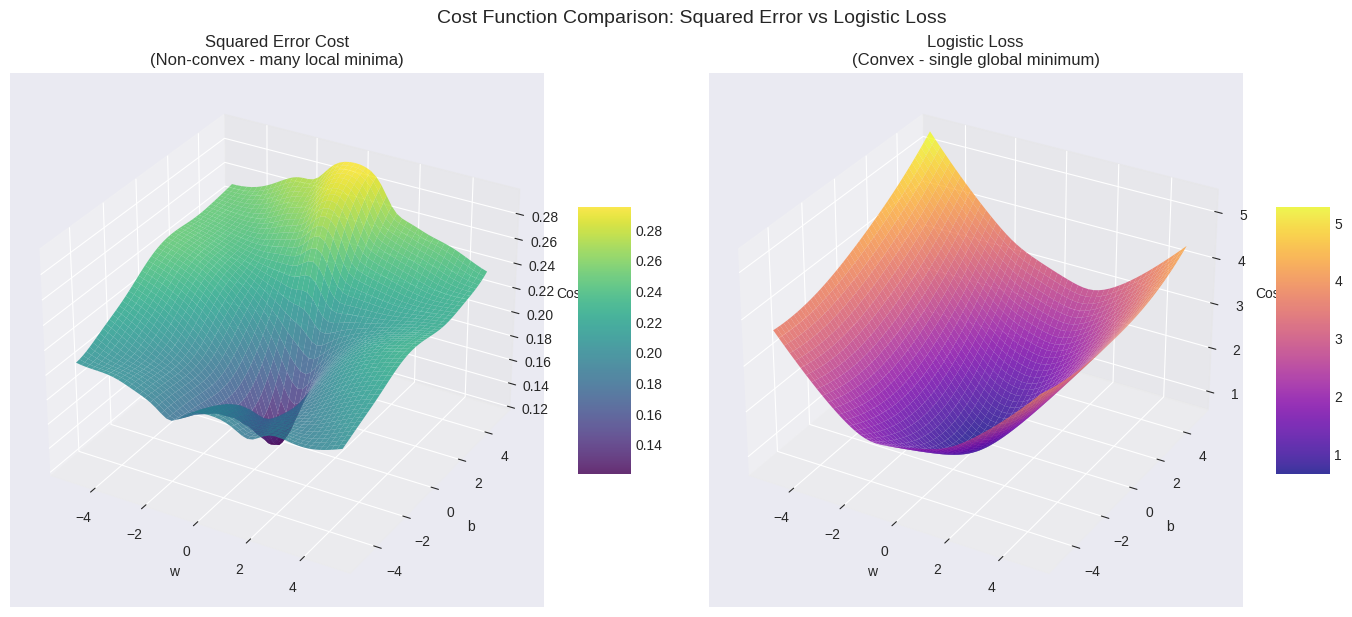

Key Insight: The logistic loss creates a smooth, convex surface
with a single global minimum, while squared error creates a
wiggly surface with multiple local minima where gradient descent can get stuck.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Create a simple dataset
np.random.seed(42)
X = np.random.randn(20, 1) * 2
y = (X.flatten() > 0).astype(int)

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Logistic regression prediction
def predict(X, w, b):
    z = w * X + b
    return sigmoid(z)

# Squared error loss for logistic regression (non-convex)
def squared_error_loss(X, y, w, b):
    predictions = predict(X, w, b)
    return 0.5 * np.mean((predictions - y) ** 2)

# Logistic loss (convex)
def logistic_loss(X, y, w, b):
    predictions = predict(X, w, b)
    # Add small epsilon to avoid log(0)
    eps = 1e-15
    return -np.mean(y * np.log(predictions + eps) +
                    (1 - y) * np.log(1 - predictions + eps))

# Create parameter grid
w_vals = np.linspace(-5, 5, 50)
b_vals = np.linspace(-5, 5, 50)
W, B = np.meshgrid(w_vals, b_vals)

# Compute cost surfaces
Z_squared = np.zeros_like(W)
Z_logistic = np.zeros_like(W)

for i in range(len(w_vals)):
    for j in range(len(b_vals)):
        Z_squared[j, i] = squared_error_loss(X, y, W[j, i], B[j, i])
        Z_logistic[j, i] = logistic_loss(X, y, W[j, i], B[j, i])

# Plot comparison
fig = plt.figure(figsize=(14, 6))

# Squared error surface (non-convex)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(W, B, Z_squared, cmap='viridis', alpha=0.8, linewidth=0, antialiased=True)
ax1.set_xlabel('w')
ax1.set_ylabel('b')
ax1.set_zlabel('Cost')
ax1.set_title('Squared Error Cost\n(Non-convex - many local minima)', fontsize=12)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# Logistic loss surface (convex)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(W, B, Z_logistic, cmap='plasma', alpha=0.8, linewidth=0, antialiased=True)
ax2.set_xlabel('w')
ax2.set_ylabel('b')
ax2.set_zlabel('Cost')
ax2.set_title('Logistic Loss\n(Convex - single global minimum)', fontsize=12)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.suptitle('Cost Function Comparison: Squared Error vs Logistic Loss', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Key Insight: The logistic loss creates a smooth, convex surface")
print("with a single global minimum, while squared error creates a")
print("wiggly surface with multiple local minima where gradient descent can get stuck.")

## 4.2 The Logistic Loss Function (Intuition)

The logistic loss function is designed to penalize wrong predictions heavily while rewarding correct ones. Let's examine it piece by piece.

### Case 1: When the true label \( $y = 1$ \)

The loss is: \( $L = -\log(f(\vec{x}))$ \)

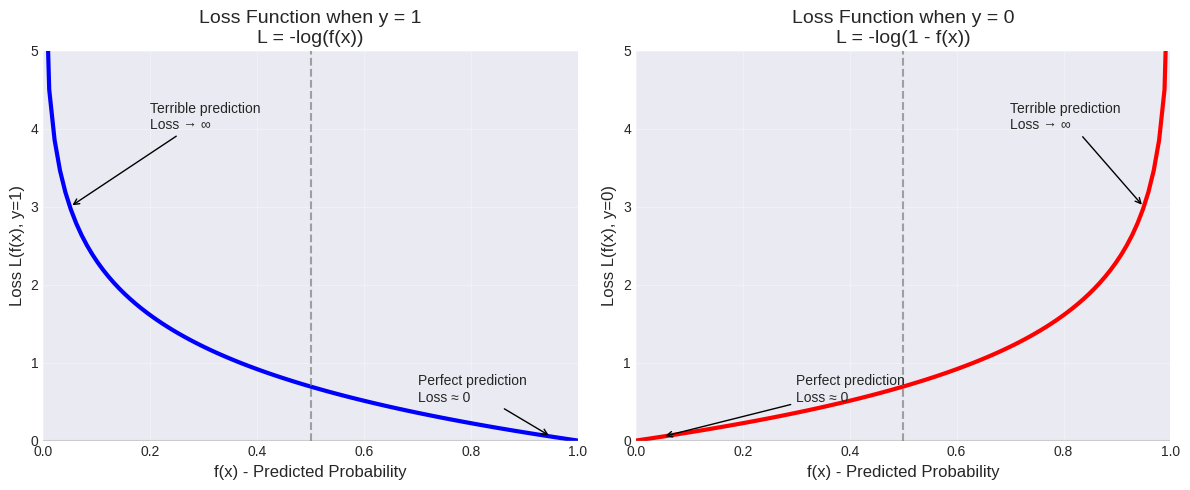

When y=1: Loss is low when f(x) is close to 1, high when f(x) is close to 0
When y=0: Loss is low when f(x) is close to 0, high when f(x) is close to 1
This asymmetric penalty is perfect for probability-based classification!


In [14]:
# Visualize loss when y = 1
f = np.linspace(0.001, 0.999, 100)  # Avoid exactly 0 or 1
loss_y1 = -np.log(f)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(f, loss_y1, 'b-', linewidth=3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='f=0.5')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('f(x) - Predicted Probability', fontsize=12)
plt.ylabel('Loss L(f(x), y=1)', fontsize=12)
plt.title('Loss Function when y = 1\nL = -log(f(x))', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 5)

# Add annotations
plt.annotate('Perfect prediction\nLoss ≈ 0', xy=(0.95, 0.05), xytext=(0.7, 0.5),
             arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('Terrible prediction\nLoss → ∞', xy=(0.05, 3), xytext=(0.2, 4),
             arrowprops=dict(arrowstyle='->', color='black'))

# Case 2: When true label y = 0
plt.subplot(1, 2, 2)
loss_y0 = -np.log(1 - f)
plt.plot(f, loss_y0, 'r-', linewidth=3)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='f=0.5')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('f(x) - Predicted Probability', fontsize=12)
plt.ylabel('Loss L(f(x), y=0)', fontsize=12)
plt.title('Loss Function when y = 0\nL = -log(1 - f(x))', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 5)

# Add annotations
plt.annotate('Perfect prediction\nLoss ≈ 0', xy=(0.05, 0.05), xytext=(0.3, 0.5),
             arrowprops=dict(arrowstyle='->', color='black'))
plt.annotate('Terrible prediction\nLoss → ∞', xy=(0.95, 3), xytext=(0.7, 4),
             arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print("When y=1: Loss is low when f(x) is close to 1, high when f(x) is close to 0")
print("When y=0: Loss is low when f(x) is close to 0, high when f(x) is close to 1")
print("This asymmetric penalty is perfect for probability-based classification!")


### Intuitive Understanding:

**When y = 1 (true label is positive):**
- If the model predicts \( f(x) = 0.9 \) (90% chance of positive), loss is small
- If the model predicts \( f(x) = 0.1 \) (10% chance of positive), loss is huge
- This makes sense - predicting low probability for something that's actually true deserves a big penalty!

**When y = 0 (true label is negative):**
- If the model predicts \( f(x) = 0.1 \) (10% chance of positive), loss is small
- If the model predicts \( f(x) = 0.9 \) (90% chance of positive), loss is huge
- Again, predicting high probability for something that's actually false deserves a big penalty!

## 4.3 Simplified Loss Function (One Equation)

The piecewise definition works, but it's cumbersome for implementation. We can combine both cases into a single equation:

$$
L(f_{\vec{w},b}(\vec{x}), y) = -y\log(f_{\vec{w},b}(\vec{x})) - (1-y)\log(1 - f_{\vec{w},b}(\vec{x}))
$$

Let's verify this works for both cases:

In [17]:
# Demonstrate that the simplified equation works for both cases
def simplified_loss(f, y):
    """Simplified logistic loss - one equation for both cases"""
    # Add tiny epsilon to avoid log(0)
    eps = 1e-15
    return -y * np.log(f + eps) - (1 - y) * np.log(1 - f + eps)

# Test values
test_f = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_cases = [0, 1]  # y = 0 and y = 1

print("=" * 60)
print("VERIFYING SIMPLIFIED LOSS FUNCTION")
print("=" * 60)

for y in test_cases:
    print(f"\n--- y = {y} ---")
    print(f"{'f(x)':<8} {'Loss':<10} {'Explanation':<30}")
    print("-" * 50)

    for f in test_f:
        loss = simplified_loss(f, y)

        if y == 1:
            expected = -np.log(f)
            explanation = f"-log({f:.1f}) = {expected:.4f}"
        else:
            expected = -np.log(1-f)
            explanation = f"-log({1-f:.1f}) = {expected:.4f}"

        print(f"{f:<8.1f} {loss:<10.4f} {explanation}")

print("\n" + "=" * 60)
print("✓ The simplified equation matches both piecewise cases!")
print("=" * 60)

VERIFYING SIMPLIFIED LOSS FUNCTION

--- y = 0 ---
f(x)     Loss       Explanation                   
--------------------------------------------------
0.1      0.1054     -log(0.9) = 0.1054
0.3      0.3567     -log(0.7) = 0.3567
0.5      0.6931     -log(0.5) = 0.6931
0.7      1.2040     -log(0.3) = 1.2040
0.9      2.3026     -log(0.1) = 2.3026

--- y = 1 ---
f(x)     Loss       Explanation                   
--------------------------------------------------
0.1      2.3026     -log(0.1) = 2.3026
0.3      1.2040     -log(0.3) = 1.2040
0.5      0.6931     -log(0.5) = 0.6931
0.7      0.3567     -log(0.7) = 0.3567
0.9      0.1054     -log(0.9) = 0.1054

✓ The simplified equation matches both piecewise cases!


## 4.4 Complete Cost Function

The cost function is simply the average loss over all training examples:

$$
J(\vec{w},b) = \frac{1}{m} \sum_{i=1}^{m} L(f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)})
$$

Substituting our simplified loss:

$$
J(\vec{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(f_{\vec{w},b}(\vec{x}^{(i)})) + (1-y^{(i)})\log(1 - f_{\vec{w},b}(\vec{x}^{(i)})) \right]
$$


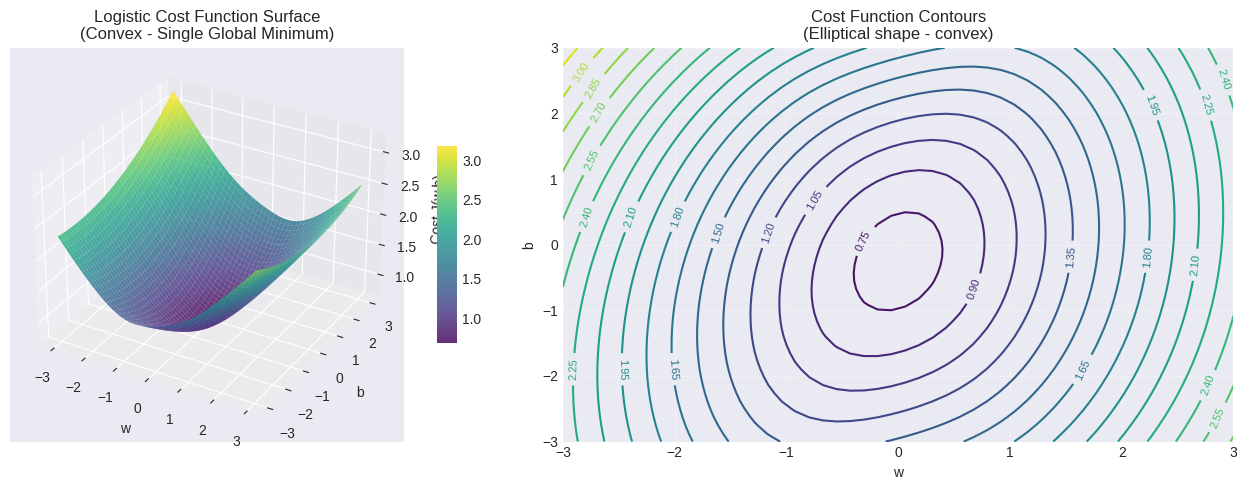

The convex shape ensures gradient descent can find the global minimum.
This is why logistic loss is preferred over squared error for classification!


In [18]:
# Visualize how cost changes with model parameters
def compute_cost(X, y, w, b):
    """Compute logistic cost for given parameters"""
    z = w * X + b
    f = 1 / (1 + np.exp(-z))
    eps = 1e-15
    return -np.mean(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))

# Create sample data
np.random.seed(42)
X_train = np.random.randn(50, 1) * 2
y_train = (X_train.flatten() + np.random.randn(50)*0.5 > 0).astype(int)

# Create mesh for visualization
w_range = np.linspace(-3, 3, 50)
b_range = np.linspace(-3, 3, 50)
W_mesh, B_mesh = np.meshgrid(w_range, b_range)
cost_mesh = np.zeros_like(W_mesh)

for i in range(len(w_range)):
    for j in range(len(b_range)):
        cost_mesh[j, i] = compute_cost(X_train, y_train, W_mesh[j, i], B_mesh[j, i])

# Plot cost surface and contours
fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(W_mesh, B_mesh, cost_mesh, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w')
ax1.set_ylabel('b')
ax1.set_zlabel('Cost J(w,b)')
ax1.set_title('Logistic Cost Function Surface\n(Convex - Single Global Minimum)', fontsize=12)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# Contour plot
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contour(W_mesh, B_mesh, cost_mesh, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w')
ax2.set_ylabel('b')
ax2.set_title('Cost Function Contours\n(Elliptical shape - convex)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The convex shape ensures gradient descent can find the global minimum.")
print("This is why logistic loss is preferred over squared error for classification!")

# 5. Visualizations

## 5.1 Loss Function Comparison: Correct vs Wrong Predictions

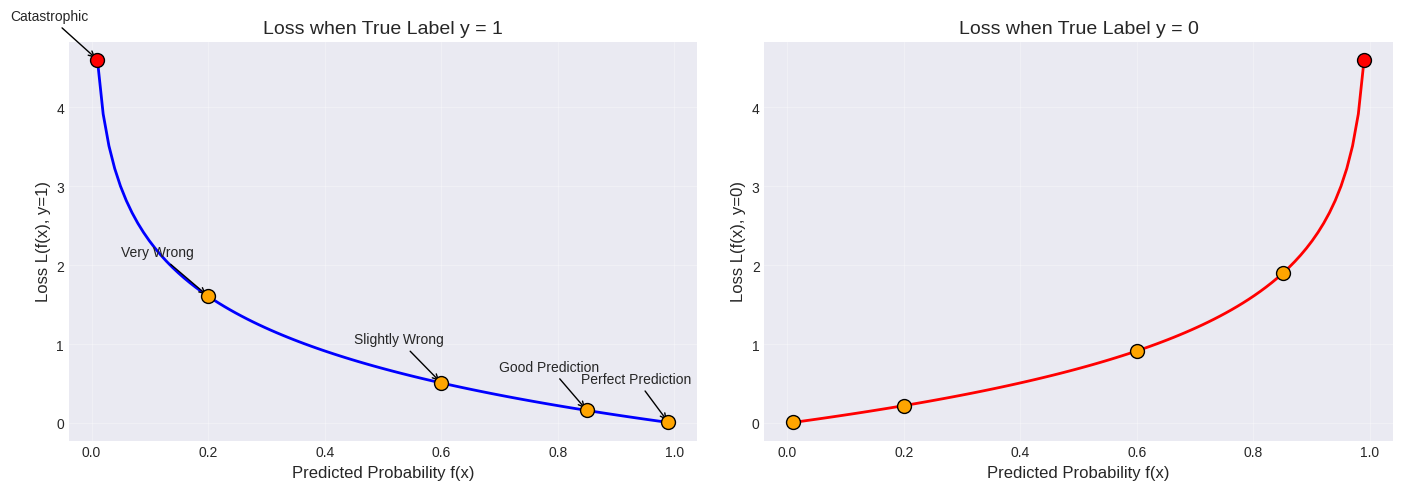

Notice how the penalty grows exponentially as predictions get worse!
This creates strong incentives for the model to be correct.


In [19]:
# Create scenarios to visualize loss values
scenarios = [
    {'name': 'Perfect Prediction', 'f': 0.99, 'y': 1, 'loss': -np.log(0.99)},
    {'name': 'Good Prediction', 'f': 0.85, 'y': 1, 'loss': -np.log(0.85)},
    {'name': 'Slightly Wrong', 'f': 0.60, 'y': 1, 'loss': -np.log(0.60)},
    {'name': 'Very Wrong', 'f': 0.20, 'y': 1, 'loss': -np.log(0.20)},
    {'name': 'Catastrophic', 'f': 0.01, 'y': 1, 'loss': -np.log(0.01)},
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for y=1
f_vals = np.linspace(0.01, 0.99, 100)
loss_vals = -np.log(f_vals)
axes[0].plot(f_vals, loss_vals, 'b-', linewidth=2)
axes[0].set_xlabel('Predicted Probability f(x)', fontsize=12)
axes[0].set_ylabel('Loss L(f(x), y=1)', fontsize=12)
axes[0].set_title('Loss when True Label y = 1', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Mark specific points
for s in scenarios:
    axes[0].scatter(s['f'], s['loss'], s=100, zorder=5,
                   color='red' if s['loss'] > 2 else 'orange',
                   edgecolors='black')
    axes[0].annotate(s['name'], xy=(s['f'], s['loss']),
                    xytext=(s['f']-0.15, s['loss']+0.5),
                    arrowprops=dict(arrowstyle='->', color='black'))

# Plot for y=0
loss_vals_y0 = -np.log(1 - f_vals)
axes[1].plot(f_vals, loss_vals_y0, 'r-', linewidth=2)
axes[1].set_xlabel('Predicted Probability f(x)', fontsize=12)
axes[1].set_ylabel('Loss L(f(x), y=0)', fontsize=12)
axes[1].set_title('Loss when True Label y = 0', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Mark points for y=0
for s in scenarios:
    loss_y0 = -np.log(1 - s['f'])
    axes[1].scatter(s['f'], loss_y0, s=100, zorder=5,
                   color='red' if loss_y0 > 2 else 'orange',
                   edgecolors='black')

plt.tight_layout()
plt.show()

print("Notice how the penalty grows exponentially as predictions get worse!")
print("This creates strong incentives for the model to be correct.")

## 5.2 Decision Boundary and Cost Relationship

/tmp/ipykernel_382/1035175555.py:69: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/1035175555.py:69: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


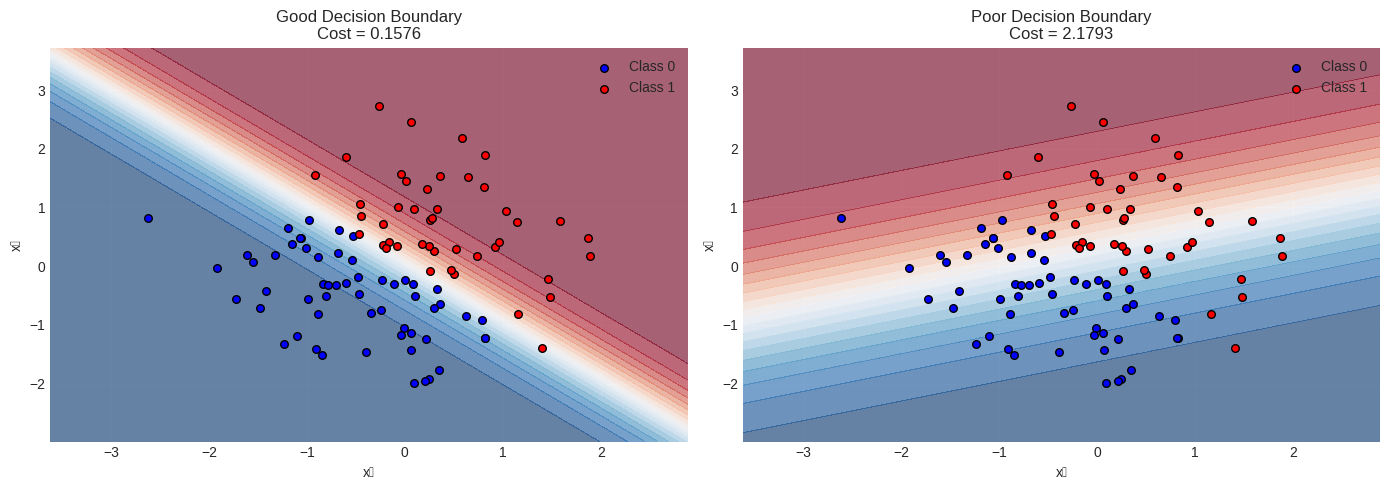

Good model cost: 0.1576 (lower is better)
Poor model cost: 2.1793 (higher is worse)
The cost function quantifies exactly how 'good' our decision boundary is!


In [20]:

# Show how different decision boundaries correspond to different costs
from sklearn.linear_model import LogisticRegression

# Generate data
np.random.seed(42)
X = np.random.randn(100, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Fit two models: good and poor
model_good = LogisticRegression()
model_good.fit(X, y)

# Create a poor model (random initialization)
class PoorModel:
    def __init__(self):
        self.coef_ = np.array([[-0.5, 1.5]])  # Poor weights
        self.intercept_ = np.array([-0.5])

model_poor = PoorModel()

# Create mesh for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Predictions for good model
Z_good = model_good.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_good = Z_good.reshape(xx.shape)

# Predictions for poor model
Z_poor = 1 / (1 + np.exp(-(model_poor.coef_[0,0] * xx +
                            model_poor.coef_[0,1] * yy +
                            model_poor.intercept_[0])))
Z_poor = Z_poor.reshape(xx.shape)

# Compute costs
def compute_bce(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

cost_good = compute_bce(y, model_good.predict_proba(X)[:, 1])
cost_poor = compute_bce(y, Z_poor.ravel()[:100])  # Use training points

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Good model
axes[0].contourf(xx, yy, Z_good, levels=20, cmap='RdBu_r', alpha=0.6)
axes[0].scatter(X[y==0, 0], X[y==0, 1], color='blue', s=30, label='Class 0', edgecolors='black')
axes[0].scatter(X[y==1, 0], X[y==1, 1], color='red', s=30, label='Class 1', edgecolors='black')
axes[0].set_title(f'Good Decision Boundary\nCost = {cost_good:.4f}', fontsize=12)
axes[0].set_xlabel('x₁')
axes[0].set_ylabel('x₂')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Poor model
axes[1].contourf(xx, yy, Z_poor, levels=20, cmap='RdBu_r', alpha=0.6)
axes[1].scatter(X[y==0, 0], X[y==0, 1], color='blue', s=30, label='Class 0', edgecolors='black')
axes[1].scatter(X[y==1, 0], X[y==1, 1], color='red', s=30, label='Class 1', edgecolors='black')
axes[1].set_title(f'Poor Decision Boundary\nCost = {cost_poor:.4f}', fontsize=12)
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Good model cost: {cost_good:.4f} (lower is better)")
print(f"Poor model cost: {cost_poor:.4f} (higher is worse)")
print("The cost function quantifies exactly how 'good' our decision boundary is!")

# 6. Code Examples

## Example 1: Implementing Logistic Cost from Scratch

In [21]:
class LogisticCost:
    """Complete implementation of logistic regression cost functions"""

    @staticmethod
    def sigmoid(z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def loss_single(f_x, y):
        """
        Compute loss for a single training example

        Args:
            f_x: Prediction (probability between 0 and 1)
            y: True label (0 or 1)

        Returns:
            Loss value
        """
        # Add tiny epsilon to avoid log(0)
        eps = 1e-15
        f_x = np.clip(f_x, eps, 1 - eps)

        if y == 1:
            return -np.log(f_x)
        else:
            return -np.log(1 - f_x)

    @staticmethod
    def loss_single_simplified(f_x, y):
        """
        Simplified loss function (one equation)
        """
        eps = 1e-15
        f_x = np.clip(f_x, eps, 1 - eps)
        return -y * np.log(f_x) - (1 - y) * np.log(1 - f_x)

    @staticmethod
    def cost_function(X, y, w, b):
        """
        Complete cost function for logistic regression

        Args:
            X: Input features (shape: m x n)
            y: True labels (shape: m,)
            w: Weights (shape: n,)
            b: Bias (scalar)

        Returns:
            Cost value J(w,b)
        """
        m = len(y)
        z = np.dot(X, w) + b
        f_x = LogisticCost.sigmoid(z)

        # Compute cost using vectorized operations
        eps = 1e-15
        f_x = np.clip(f_x, eps, 1 - eps)
        cost = -np.mean(y * np.log(f_x) + (1 - y) * np.log(1 - f_x))

        return cost

    @staticmethod
    def gradient(X, y, w, b):
        """
        Compute gradients for gradient descent

        Returns:
            dw, db: Gradients with respect to w and b
        """
        m = len(y)
        z = np.dot(X, w) + b
        f_x = LogisticCost.sigmoid(z)

        dw = (1/m) * np.dot(X.T, (f_x - y))
        db = (1/m) * np.sum(f_x - y)

        return dw, db

# Test the implementation
np.random.seed(42)
X_test = np.random.randn(10, 2)
y_test = (X_test[:, 0] + X_test[:, 1] > 0).astype(int)
w_test = np.random.randn(2)
b_test = np.random.randn()

# Compute cost
cost = LogisticCost.cost_function(X_test, y_test, w_test, b_test)
dw, db = LogisticCost.gradient(X_test, y_test, w_test, b_test)

print("=" * 60)
print("TESTING LOGISTIC COST IMPLEMENTATION")
print("=" * 60)
print(f"Cost J(w,b): {cost:.6f}")
print(f"Gradient dw: [{dw[0]:.6f}, {dw[1]:.6f}]")
print(f"Gradient db: {db:.6f}")

# Verify simplified loss matches piecewise loss
print("\n" + "=" * 60)
print("VERIFYING LOSS FUNCTIONS")
print("=" * 60)

test_f = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
test_y = np.array([0, 1, 0, 1, 0])

print(f"{'f(x)':<8} {'y':<4} {'Piecewise Loss':<15} {'Simplified Loss':<15} {'Match?':<8}")
print("-" * 60)

for f, y in zip(test_f, test_y):
    loss_piecewise = LogisticCost.loss_single(f, y)
    loss_simplified = LogisticCost.loss_single_simplified(f, y)
    match = "✓" if abs(loss_piecewise - loss_simplified) < 1e-10 else "✗"
    print(f"{f:<8.1f} {y:<4} {loss_piecewise:<15.6f} {loss_simplified:<15.6f} {match:<8}")

TESTING LOGISTIC COST IMPLEMENTATION
Cost J(w,b): 0.490448
Gradient dw: [-0.091002, -0.292456]
Gradient db: 0.065580

VERIFYING LOSS FUNCTIONS
f(x)     y    Piecewise Loss  Simplified Loss Match?  
------------------------------------------------------------
0.1      0    0.105361        0.105361        ✓       
0.3      1    1.203973        1.203973        ✓       
0.5      0    0.693147        0.693147        ✓       
0.7      1    0.356675        0.356675        ✓       
0.9      0    2.302585        2.302585        ✓       


## Example 2: Gradient Descent for Logistic Regression


Training Logistic Regression with Gradient Descent...
Iteration    0, Cost: 0.693147
Iteration  200, Cost: 0.286489
Iteration  400, Cost: 0.253526
Iteration  600, Cost: 0.241574
Iteration  800, Cost: 0.235715


/tmp/ipykernel_382/2451349250.py:95: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_382/2451349250.py:95: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()


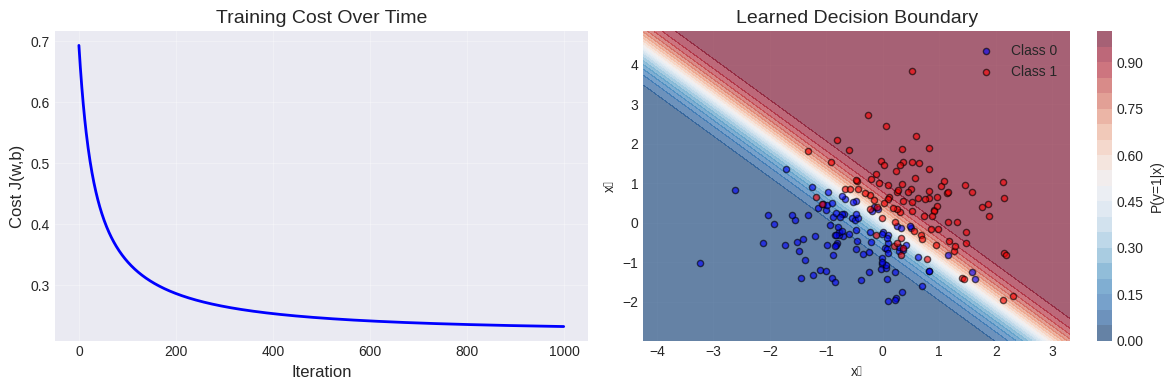


Final cost: 0.232427
Final weights: w₁ = 3.1380, w₂ = 3.0096
Final bias: b = -0.1473


In [22]:
class LogisticRegressionGD:
    """Logistic Regression trained with Gradient Descent"""

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.cost_history = []

    def fit(self, X, y):
        """Train the model using gradient descent"""
        m, n = X.shape

        # Initialize parameters
        self.w = np.zeros(n)
        self.b = 0

        # Gradient descent
        for i in range(self.n_iterations):
            # Forward pass
            z = np.dot(X, self.w) + self.b
            f_x = 1 / (1 + np.exp(-z))

            # Compute cost
            eps = 1e-15
            f_x_clipped = np.clip(f_x, eps, 1 - eps)
            cost = -np.mean(y * np.log(f_x_clipped) +
                           (1 - y) * np.log(1 - f_x_clipped))
            self.cost_history.append(cost)

            # Compute gradients
            dw = (1/m) * np.dot(X.T, (f_x - y))
            db = (1/m) * np.sum(f_x - y)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Print progress
            if i % 200 == 0:
                print(f"Iteration {i:4d}, Cost: {cost:.6f}")

    def predict_proba(self, X):
        """Predict probabilities"""
        z = np.dot(X, self.w) + self.b
        return 1 / (1 + np.exp(-z))

    def predict(self, X, threshold=0.5):
        """Predict class labels"""
        return (self.predict_proba(X) >= threshold).astype(int)

# Generate synthetic data
np.random.seed(42)
X_train = np.random.randn(200, 2)
y_train = (X_train[:, 0] + X_train[:, 1] + np.random.randn(200)*0.5 > 0).astype(int)

# Train model
model = LogisticRegressionGD(learning_rate=0.1, n_iterations=1000)
print("Training Logistic Regression with Gradient Descent...")
print("=" * 50)
model.fit(X_train, y_train)

# Plot training curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(model.cost_history, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost J(w,b)', fontsize=12)
plt.title('Training Cost Over Time', fontsize=14)
plt.grid(True, alpha=0.3)

# Plot decision boundary
plt.subplot(1, 2, 2)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1|x)')
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
            color='blue', s=20, label='Class 0', alpha=0.6, edgecolors='black')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
            color='red', s=20, label='Class 1', alpha=0.6, edgecolors='black')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Learned Decision Boundary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal cost: {model.cost_history[-1]:.6f}")
print(f"Final weights: w₁ = {model.w[0]:.4f}, w₂ = {model.w[1]:.4f}")
print(f"Final bias: b = {model.b:.4f}")

---

# 7. Key Takeaways

1. **Squared error cost function fails for logistic regression** because it creates a **non-convex** surface with many local minima, making gradient descent unreliable.

2. **Logistic loss is specifically designed for classification** - it heavily penalizes confident wrong predictions while rewarding correct ones.

3. **The loss function is asymmetric**:
   - When \( $y=1$ \), loss = \($-\log(f(x))$\)
   - When \( $y=0$ \), loss = \($-\log(1-f(x))$\)

4. **A single simplified equation** works for both cases: \( $L = -y\log(f(x)) - (1-y)\log(1-f(x))$ \)

5. **The cost function** \( $J(\vec{w},b)$ \) is just the average loss over all training examples.

6. **Convexity is crucial** - the logistic cost function is convex, guaranteeing that gradient descent will find the global minimum.

7. **Maximum likelihood estimation** is the statistical principle behind this cost function - it ensures efficient parameter estimation.

8. **Lower cost = better fit** - the cost function quantifies exactly how well our model's parameters explain the training data.

---

# 8. Quick Revision

## Key Formulas

| **Formula** | **Description** |
|-------------|-----------------|
| \( $L(f(x), y) = \begin{cases} -\log(f(x)) & \text{if } y=1 \\ -\log(1-f(x)) & \text{if } y=0 \end{cases}$ \) | Piecewise logistic loss |
| \( $L(f(x), y) = -y\log(f(x)) - (1-y)\log(1-f(x))$ \) | Simplified logistic loss (single equation) |
| \( $J(\vec{w},b) = \frac{1}{m} \sum_{i=1}^{m} L(f_{\vec{w},b}(\vec{x}^{(i)}), y^{(i)})$ \) | Cost function definition |
| \( $J(\vec{w},b) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)}\log(f(\vec{x}^{(i)})) + (1-y^{(i)})\log(1-f(\vec{x}^{(i)}))]$ \) | Complete logistic cost |

## Key Properties

| **Property** | **Why It Matters** |
|--------------|---------------------|
| **Convex** | Guarantees gradient descent finds global minimum |
| **Asymmetric penalty** | Correctly handles probability-based predictions |
| **Derived from MLE** | Statistically optimal for parameter estimation |
| **Continuous** | Enables gradient-based optimization |

## Common Misconceptions

| **Misconception** | **Truth** |
|-------------------|-----------|
| "Squared error works fine for classification" | ❌ Creates non-convex surface with many local minima |
| "Loss and cost are the same thing" | ❌ Loss is for one example; cost is average over all examples |
| "The cost function is arbitrary" | ❌ Derived from maximum likelihood estimation (statistically principled) |
| "Higher cost sometimes means better model" | ❌ Lower cost always means better fit to training data |

---

